# Mario RL: Environment and Observation Setup

This notebook follows the PyTorch Mario RL tutorial using a modern Gymnasium-compatible stack. These first cells create the game environment, inspect one agent decision, and begin preprocessing its observations.

### Why this sequence matters

Mario starts as a large RGB game image. The following wrappers reduce repeated decisions, remove mostly unnecessary color, shrink the image, and retain a short history of frames. Together, those transformations give the agent a smaller input that still shows Mario's position and motion.

## 1. Import the environment tools

This cell imports Gymnasium, the Super Mario Bros environment, and `JoypadSpace`, which converts simple numbered actions into NES button presses. `pprint` formats the environment's extra diagnostic information so it is easier to read.

### Why these tools come first

The environment produces observations, rewards, and episode-ending signals. Wrappers let us change those observations in small, testable layers without changing Mario's game itself. That separation makes it clear which transformation caused each shape change.

In [1]:
# Gymnasium API (modernized stack: gymnasium + gym-super-mario-bros>=9.1)
from pprint import pprint

import gym_super_mario_bros
import gymnasium as gym
from nes_py.wrappers import JoypadSpace

## 2. Create and inspect one environment step

This cell creates Mario level 1-1 and restricts the agent to two actions: move right, or move right while jumping. It resets the game, takes action `0`, and prints the resulting image shape, reward, episode-ending flags, and diagnostic `info` dictionary.

### Why inspect the unmodified environment

This is the baseline: it shows exactly what the game provides before any wrapper transforms it. Knowing that the raw observation is `(240, 256, 3)` lets us verify that later shape changes are intentional. Restricting the actions also makes the first learning problem smaller while preserving the tutorial's right-and-jump experiment.

In [2]:
env = gym_super_mario_bros.make(
    "SuperMarioBros-1-1-v0",
    render_mode="rgb_array",
)

env = JoypadSpace(env, [["right"], ["right", "A"]])

obs, info = env.reset()
next_obs, reward, terminated, truncated, info = env.step(0)

episode_done = terminated or truncated

print("next observation:", next_obs.shape)
print("reward:", reward)
print("terminated:", terminated)
print("truncated:", truncated)
pprint(info)

next observation: (240, 256, 3)
reward: 0.0
terminated: False
truncated: False
{'area': 1,
 'clear': False,
 'coins': 0,
 'death': False,
 'enemy_types': (0, 0, 0, 0, 0),
 'flag_get': False,
 'game': 'smb1',
 'game_family': 'smb1',
 'is_dead': False,
 'is_dying': False,
 'is_game_over': False,
 'is_stage_over': False,
 'is_world_over': False,
 'left_x_pos': 40,
 'level': 0,
 'life': 2,
 'lives': 2,
 'player_state': 8,
 'powerup_level': 0,
 'progress': 40,
 'progress_max': 40,
 'reward_components': {'coins': 0.0,
                       'completion': 0.0,
                       'death': 0.0,
                       'powerup': 0.0,
                       'progress': 0.0,
                       'score': 0.0,
                       'time': 0.0},
 'reward_total_clipped': 0.0,
 'reward_total_unclipped': 0.0,
 'rom_mode': 'vanilla',
 'score': 0,
 'single_stage': True,
 'stage': 1,
 'status': 'small',
 'status_value': 0,
 'target_stage': 1,
 'target_world': 1,
 'task_id': 'SuperMarioBros-1-1-v0'

## 3. Define `SkipFrame`

`SkipFrame` is a Gymnasium wrapper that repeats one selected action for several game frames. It adds the rewards earned across those frames, returns the final observation, and stops early when the episode ends. The positive `skip` check prevents a zero-iteration loop with no observation to return.

### Why repeat one action

Mario changes only a little between adjacent game frames, so choosing a new action every frame creates many nearly identical decisions. Repeating an action for four frames reduces that decision load and speeds learning. Summing the intermediate rewards ensures the agent still receives credit for everything that happened during those four frames.

In [3]:
class SkipFrame(gym.Wrapper):
    """Repeat one action for several frames and sum its rewards."""

    def __init__(self, env: gym.Env, skip: int) -> None:
        super().__init__(env)
        if skip < 1:
            raise ValueError("skip must be at least 1")
        self._skip = skip


    def step(self, action: int) -> tuple:
        total_reward = 0.0

        for _ in range(self._skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            total_reward += reward

            if terminated or truncated:
                break

        return obs, total_reward, terminated, truncated, info

## 4. Test `SkipFrame`

This cell wraps the existing Mario environment with `skip=4`, resets it, and takes one rightward action. The image shape should remain `(240, 256, 3)` because this wrapper changes decision frequency, not image size; the printed reward represents up to four game frames.

### Why test this before the image transformations

Each wrapper should change one idea at a time. This test confirms that frame skipping changes when the agent decides, while leaving the RGB pixels alone. That makes later grayscale and resize results easier to trust.

In [4]:
wrapped_env = SkipFrame(env, skip=4)

obs, info = wrapped_env.reset()
next_obs, reward, terminated, truncated, info = wrapped_env.step(0)

print("shape:", next_obs.shape)
print("four-frame reward:", reward)
print("episode ended:", terminated or truncated)

shape: (240, 256, 3)
four-frame reward: 0.0
episode ended: False


## 5. Visualize the raw observation

This cell displays the RGB image currently returned to the agent after frame skipping. It is a human-facing check of the same pixel data that later preprocessing wrappers will transform.

### Why keep a visual baseline

A printed shape cannot show whether Mario, platforms, and enemies are visible. This RGB image is the before-picture for the transformations that follow. Comparing it with the resized grayscale image helps us check that useful scene structure survived.

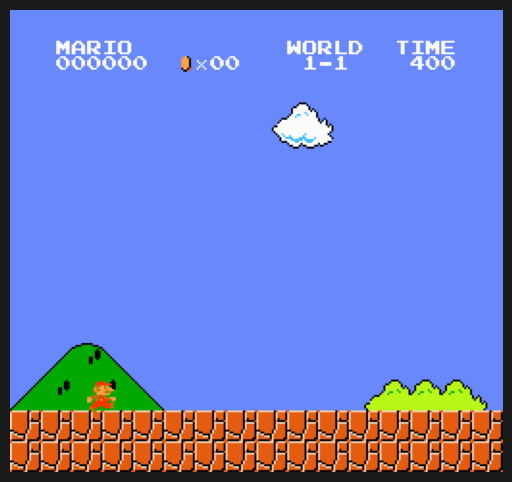

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(next_obs)
plt.axis("off")
plt.show()

## 6. Convert observations to grayscale

This cell removes RGB color channels while preserving Mario's visible shapes. The result is one brightness value per pixel, which reduces the observation from three dimensions to two.

### Why remove color

For this task, edges, platforms, gaps, and Mario's position are more useful than the exact red, green, and blue values. One brightness value per pixel removes redundant color information, so the agent stores and processes fewer numbers. The game geometry remains visible, which is what the later network needs to learn movement decisions.

In [6]:
from gymnasium.wrappers import GrayscaleObservation

gray_env = GrayscaleObservation(wrapped_env, keep_dim=False)

gray_obs, info = gray_env.reset()
gray_next_obs, reward, terminated, truncated, info = gray_env.step(0)
print("grayscale shape:", gray_next_obs.shape)
print("dtype:", gray_next_obs.dtype)
print("reward:", reward)

grayscale shape: (240, 256)
dtype: uint8
reward: 0.0


## 7. Resize observations

This cell shrinks each grayscale Mario frame from `(240, 256)` to `(84, 84)`. It also converts brightness values from integers between 0 and 255 into decimal values between 0.0 and 1.0.

### Why make the image smaller and normalize it

The raw frame has more than 60,000 pixels, much of which is fine visual detail the first agent does not need. Reducing it to `84 × 84` lowers memory use and makes the future neural network faster to train. Dividing brightness by 255 puts every pixel on the consistent 0.0-to-1.0 scale, which makes later model calculations more stable.

In [7]:
import numpy as np
import torch
from torchvision import transforms as T


class ResizeObservation(gym.ObservationWrapper):
    """Resize a grayscale observation to a normalized square image.

    An ObservationWrapper changes images returned by an environment, not its actions or rewards.
    """

    def __init__(self, env: gym.Env, shape: int | tuple[int, int]) -> None:
        super().__init__(env)

        self.shape: tuple[int, int] = (
            (shape, shape) if isinstance(shape, int) else shape
        )
        # Prepare a smoother transform that downsamples every incoming image.
        self._resize = T.Resize(self.shape, antialias=True)
        # Describe output pixels: normalized float32 brightness values in the new shape.
        self.observation_space = gym.spaces.Box(
            low=0.0,  # Black.
            high=1.0,  # White.
            shape=self.shape,  # The resized height and width.
            dtype=np.float32,  # Fractional pixel values.
        )

    # Gymnasium calls this method whenever the wrapped environment returns an observation.
    def observation(self, observation: np.ndarray) -> np.ndarray:
        # The grayscale input starts as (height, width). `unsqueeze(0)` adds a
        # first axis of size one, producing (1, height, width) without adding pixels.
        image = torch.as_tensor(observation, dtype=torch.float32).unsqueeze(0)
        # Resize produces (1, 84, 84). `squeeze(0)` removes that first size-one
        # channel axis, returning (84, 84), then division scales brightness to 0.0-1.0.
        resized = self._resize(image).squeeze(0) / 255.0
        # Return a NumPy array because Gymnasium environments use NumPy observations.
        return resized.numpy()


In [8]:
resized_env = ResizeObservation(gray_env, shape=84)

resized_obs, info = resized_env.reset()
resized_next_obs, reward, terminated, truncated, info = resized_env.step(0)

print("resized shape:", resized_next_obs.shape)
print("dtype:", resized_next_obs.dtype)
print("min/max:", resized_next_obs.min(), resized_next_obs.max())

resized shape: (84, 84)
dtype: float32
min/max: 0.15468283 0.9882354


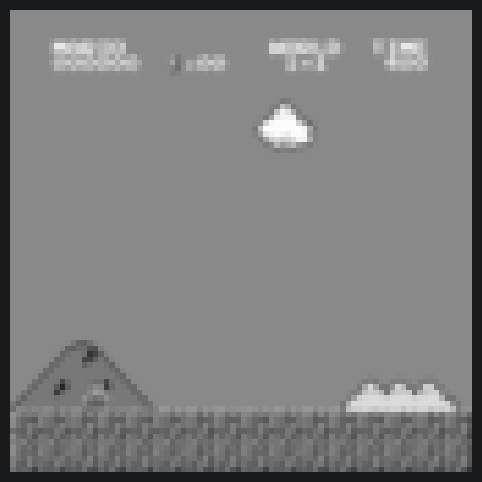

In [9]:
plt.figure(figsize=(8, 6))
plt.imshow(resized_next_obs, cmap="gray", vmin=0.0, vmax=1.0)
plt.axis("off")
plt.show()

## 8. Stack consecutive frames

One image cannot show Mario's direction or speed. This wrapper keeps the four most recent resized grayscale frames so the agent can infer motion. The resulting observation has shape `(4, 84, 84)`.

### Why keep four moments in time

A single frame shows where Mario is, but it cannot show whether he is rising, falling, or moving toward a gap. Four consecutive frames form a short visual history, allowing the agent to infer direction and speed from changes between images. This is the final tutorial preprocessing transformation before the neural network receives observations.

In [10]:
from gymnasium.wrappers import FrameStackObservation

stacked_env = FrameStackObservation(resized_env, stack_size=4)

stacked_obs, info = stacked_env.reset()
stacked_next_obs, reward, terminated, truncated, info = stacked_env.step(0)

print("stacked shape:", stacked_next_obs.shape)
print("dtype:", stacked_next_obs.dtype)
print("min/max:", stacked_next_obs.min(), stacked_next_obs.max())

stacked shape: (4, 84, 84)
dtype: float32
min/max: 0.15468283 0.9882354


## 9. MarioNet: predict action values from frames

`MarioNet` receives four stacked grayscale Mario frames and predicts one Q value for each available action. A Q value is the network's current estimate of how useful an action is from the observed state.

### Why use two networks

The online network will learn from experience. The target network starts as an identical frozen copy and changes only occasionally in the later DDQN update step. Keeping that reference more stable helps learning avoid chasing a constantly changing target.

In [11]:
from mario_agent import Mario
from mario_net import MarioNet


C:\Users\giloz\dev\mario_rl_tuto\.venv\Lib\site-packages\torchrl\data\replay_buffers\samplers.py:36: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


In [12]:
state_dim = tuple(stacked_env.observation_space.shape)
action_dim = stacked_env.action_space.n

mario_net = MarioNet(state_dim, action_dim)
state_batch = torch.as_tensor(stacked_obs, dtype=torch.float32).unsqueeze(0)
q_values = mario_net(state_batch, model="online")

print("state batch shape:", tuple(state_batch.shape))
print("Q-value shape:", tuple(q_values.shape))
print("Q-values:", q_values.detach().numpy())

state batch shape: (1, 4, 84, 84)
Q-value shape: (1, 2)
Q-values: [[-0.02459928  0.04063624]]


## 10. Agent: choose actions with epsilon-greedy exploration

The `Mario` agent will eventually act, remember experiences, and learn from them. This section introduces action selection first; we will define and test `MarioNet` before creating a `Mario` object so the notebook remains runnable.

### Epsilon is the exploration rate

`ε` (epsilon) is the conventional mathematical name for the code attribute `self.exploration_rate`; they are the same setting, not two separate values. The agent draws a random number from 0.0 up to, but not including, 1.0. If that number is less than ε, Mario explores by choosing a random action; otherwise, Mario exploits by choosing the action with the highest predicted Q value.

### Why explore before exploiting

At the start, the neural network has not learned which action is useful, so `ε = 1.0` makes every action random. After each decision, `self.exploration_rate` is multiplied by a small decay value until it reaches its minimum of `0.1`. That gradually shifts Mario from gathering varied experience toward using learned predictions, while preserving occasional exploration.

### Implementation note

`MarioNet` lives in `mario_net.py`, and the evolving `Mario` agent lives in `mario_agent.py`. Keeping the network and agent in separate pure Python modules lets the notebook focus on demonstrations and tests.


## 11. Test Mario's first action

This cell creates one `Mario` agent using the stacked-frame shape and the two available actions.

It then asks the agent to choose an action from the current observation.

### Why test before learning

Creating the agent confirms that `MarioNet` is now available when `Mario` constructs its online and target networks. Because the
 initial exploration rate is 1.0, the first action is random; this is expected while the network has not trained.

In [13]:
mario = Mario(
    state_dim=state_dim,
    action_dim=action_dim,
    save_dir=Path("checkpoints")
)

action = mario.act(stacked_obs)

print(f"chosen action: {action}")
print(f"exploration rate: {mario.exploration_rate}")
print(f"steps taken {mario.curr_step}")

NameError: name 'Path' is not defined